# Session 1: Linear Models & Overfitting

Run the setup cell first, then work top to bottom. Search for `TODO` to find every blank.

**How to read this notebook**

Every code cell is labeled in its title bar:
- **Run only**: setup, plots, and demos. Run the cell and move on; the code is just scaffolding, nothing to study. (These show collapsed; click the title to peek if you're curious.)
- **Edit & learn**: the cells to read, fill in, and turn knobs in. These hold the scikit-learn patterns worth taking into your own work, and every reusable line is commented.

Run the next two cells first. The one below imports the tools we'll use. Most of the functions that do the actual machine learning come from scikit-learn (`sklearn`).

In [ ]:
# numpy = number crunching, matplotlib = plots. These are general tools, not ML.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# The machine learning itself comes from scikit-learn (sklearn): the models,
# the train/test split, cross-validation, and the scoring all live here.
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

In [ ]:
#@title Run only · setup (data, plot helpers)
# Plumbing only: fixed seed, data generation, and the plot helpers. (Imports are in the cell above.)

SEED = 42

TEAL  = "#1b9e9e"
CORAL = "#ff7f50"
GRAY  = "#9aa0a6"
RED   = "#d62728"
PURPLE = "#7b5aa6"        # over-budget class in the sigmoid plot
BUDGET = 400000          # a house at or above this price is "over budget"

def make_house_data():
    np.random.seed(SEED)
    n = 80
    sqft  = np.random.uniform(600, 3400, n)
    price = 190 * sqft + 60000 + np.random.normal(0, 38000, n)
    sqft  = sqft.round(0)
    price = price.round(-2)                       # round to nearest $100
    # a few real-world outliers: a big house priced low (needs work),
    # a tiny one priced high (prime location), plus two milder ones
    sqft[0] = 2800; price[0] = 450000
    sqft[1] = 1250; price[1] = 440000
    sqft[2] = 3250; price[2] = 390000
    sqft[3] = 900;  price[3] = 500000
    price = np.clip(price, 80000, None)
    over_budget = (price >= BUDGET).astype(int)
    return sqft, price, over_budget

sqft, price, over_budget = make_house_data()
X = sqft.reshape(-1, 1)   # sklearn wants a 2-D column of features

def _style(ax, title, xlabel="square footage (sq ft)", ylabel="price ($)"):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4)

def scatter_data(ax=None, show_budgetline=True):
    if ax is None: fig, ax = plt.subplots(figsize=(7,4.5))
    ax.scatter(sqft, price, color=TEAL, s=40, alpha=0.85, label="data")
    if show_budgetline:
        ax.axhline(BUDGET, color=GRAY, linestyle=":", label=f"budget = ${BUDGET:,}")
    _style(ax, "Square footage vs price")
    ax.legend(); return ax

def plot_line(model):
    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.scatter(sqft, price, color=TEAL, s=40, alpha=0.85, label="data")
    grid = np.linspace(sqft.min(), sqft.max(), 200).reshape(-1,1)
    ax.plot(grid, model.predict(grid), color=CORAL, lw=2.5, label="model's guess")
    for xi, yi in zip(sqft, price):
        ax.plot([xi, xi], [yi, model.predict([[xi]])[0]], color=RED,
                linestyle="--", lw=0.7, alpha=0.5)
    _style(ax, "A line through the cloud"); ax.legend(); return ax

def plot_threshold_view(clf, threshold):
    """Run-only: left = the S-curve with the threshold cut; right = the confusion
    matrix that results. Returns accuracy / precision / recall for that threshold."""
    from matplotlib.patches import Rectangle
    probs = clf.predict_proba(X)[:, 1]
    pred  = (probs >= threshold).astype(int)
    tp = int(((pred==1)&(over_budget==1)).sum()); tn = int(((pred==0)&(over_budget==0)).sum())
    fp = int(((pred==1)&(over_budget==0)).sum()); fn = int(((pred==0)&(over_budget==1)).sum())
    acc  = (tp+tn)/len(over_budget)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
    # left: the S-curve with the threshold cut and the decision boundary
    m0 = over_budget==0; m1 = over_budget==1
    axL.scatter(sqft[m0], over_budget[m0], color=TEAL,   s=32, alpha=0.8, label="within budget (0)")
    axL.scatter(sqft[m1], over_budget[m1], color=PURPLE, s=32, alpha=0.8, label="over budget (1)")
    grid = np.linspace(sqft.min(), sqft.max(), 200).reshape(-1,1)
    axL.plot(grid, clf.predict_proba(grid)[:,1], color=CORAL, lw=2.5, label="P(over budget)")
    axL.axhline(threshold, color=GRAY, linestyle=":", label=f"threshold = {threshold}")
    xb = (np.log(threshold/(1-threshold)) - clf.intercept_[0]) / clf.coef_[0,0]
    axL.axvline(xb, color="k", linestyle="--", lw=1.2)
    _style(axL, "The threshold cuts the S-curve", ylabel="P(over budget)")
    axL.legend(fontsize=8)
    # right: the four boxes -- correct ones teal, mistakes red
    cm   = [[tn, fp],[fn, tp]]
    note = [["within, called within\n(correct)", "within, called over\n(false alarm)"],
            ["over, called within\n(missed)",    "over, called over\n(correct)"]]
    good = [[True,False],[False,True]]
    for r in range(2):
        for c in range(2):
            axR.add_patch(Rectangle((c, 1-r), 1, 1,
                          color=(TEAL if good[r][c] else RED), alpha=0.28, ec="k"))
            axR.text(c+0.5, 1-r+0.5, f"{cm[r][c]}\n{note[r][c]}", ha="center", va="center", fontsize=9)
    axR.set_xlim(0,2); axR.set_ylim(0,2)
    axR.set_xticks([0.5,1.5]); axR.set_xticklabels(["predicted within","predicted over"])
    axR.set_yticks([1.5,0.5]); axR.set_yticklabels(["actual within","actual over"])
    axR.set_title(f"Confusion matrix  (accuracy {acc:.2f})")
    fig.tight_layout()
    return {"accuracy":acc, "precision":prec, "recall":rec}

def plot_sweep(degrees, train_scores, val_scores):
    fig, ax = plt.subplots(figsize=(7.5,4.5))
    ax.plot(degrees, train_scores, "-o", color=CORAL, label="train score")
    ax.plot(degrees, val_scores,   "-o", color=GRAY,  label="validation score")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylim(-1, 1.05)
    _style(ax, "Train vs validation score as the model gets more complex",
           xlabel="polynomial degree", ylabel="R² score (higher is better)")
    ax.legend(); return ax

def plot_poly_fit(degree, X_train, y_train):
    fig, ax = plt.subplots(figsize=(7,4.5))
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                          LinearRegression()).fit(X_train, y_train)
    ax.scatter(X_train.ravel(), y_train, color=TEAL, s=45, label="train data")
    grid = np.linspace(sqft.min(), sqft.max(), 400).reshape(-1,1)
    ax.plot(grid, model.predict(grid), color=CORAL, lw=2.5, label=f"degree {degree} fit")
    ax.set_ylim(0, 800000)
    _style(ax, f"Degree-{degree} fit"); ax.legend(); return ax

def show_model_learning(lr, steps=200, snaps=(0,1,3,8,30,200)):
    """Watch a line improve over rounds of gradient descent (run-only spectacle).
    Standardizes internally so the nudges are well-scaled, then maps the line
    back to real dollar units for plotting. The loss is clipped only so a
    too-large learning rate can't break the chart."""
    x, y = sqft, price
    xm, xs = x.mean(), x.std(); ym, ys = y.mean(), y.std()
    xz = (x - xm) / xs; yz = (y - ym) / ys
    w = b = 0.0; losses = []; saved = {}
    for t in range(steps + 1):
        err = w * xz + b - yz
        losses.append(min(float((err ** 2).mean()), 5.0))
        if t in snaps:
            slope = w * ys / xs
            intercept = ym + ys * b - w * ys * xm / xs
            saved[t] = (slope, intercept, losses[-1])
        w -= lr * 2 * np.mean(err * xz); b -= lr * 2 * np.mean(err)
        w = float(np.clip(w, -50, 50)); b = float(np.clip(b, -50, 50))
    fig = plt.figure(figsize=(11, 7))
    gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1.1], hspace=0.5, wspace=0.25)
    grid = np.linspace(x.min(), x.max(), 100)
    for i, t in enumerate(snaps):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        slope, intercept, loss = saved[t]
        ax.scatter(x, y, color=TEAL, s=12, alpha=0.6)
        ax.plot(grid, slope * grid + intercept, color=CORAL, lw=2)
        ax.set_title(f"round {t}   loss={loss:.2f}", fontsize=10)
        ax.set_ylim(0, 800000); ax.set_xticks([]); ax.set_yticks([])
    axl = fig.add_subplot(gs[2, :])
    axl.plot(range(len(losses)), losses, color=CORAL, lw=2)
    axl.set_title(f"the loss falls as the line improves (learning rate = {lr})", fontsize=11)
    axl.set_xlabel("round"); axl.set_ylabel("loss (lower=better)")
    axl.grid(True, linestyle="--", alpha=0.4)
    fig.suptitle("A model learning a line, one nudge at a time", fontsize=14, y=0.98)
    return fig

def make_house_features():
    """A wider house table: 5 features that really move the price, plus 5 named
    features a listing might mention but that do NOT set the price."""
    np.random.seed(SEED)
    n = 200
    sqft            = np.random.uniform(600, 3400, n)
    bedrooms        = np.random.randint(1, 6, n)
    bathrooms       = np.random.randint(1, 4, n)
    lot_size        = np.random.uniform(1000, 12000, n)   # square feet of land
    age             = np.random.uniform(0, 80, n)
    # named noise: really appears in listings, but has no effect on price
    wall_color      = np.random.randint(0, 8, n)          # a paint-color code
    roof_color      = np.random.randint(0, 8, n)
    lucky_number    = np.random.randint(1, 100, n)        # seller's favorite number
    listing_day     = np.random.randint(0, 7, n)          # day of week it was listed
    coffee_distance = np.random.uniform(0, 5, n)          # miles to nearest coffee shop
    # only the first five features go into the true price
    price = (150*sqft + 18000*bedrooms + 30000*bathrooms + 6*lot_size - 900*age + 50000
             + np.random.normal(0, 30000, n))
    cols  = [sqft, bedrooms, bathrooms, lot_size, age,
             wall_color, roof_color, lucky_number, listing_day, coffee_distance]
    return np.column_stack(cols), price

HOUSE_FEATURES = ["sqft", "bedrooms", "bathrooms", "lot size", "age",
                  "wall color", "roof color", "lucky number", "listing day", "coffee distance"]
N_REAL = 5                       # the first five are the real drivers; the rest are noise
X_house, price_house = make_house_features()

def plot_feature_weights(model, names, n_real=5):
    """One labeled bar per feature: how much it moves the price. Real drivers are
    teal, the named-noise features gray. With a penalty on, the noise bars go to 0."""
    coefs = model.named_steps[list(model.named_steps)[-1]].coef_
    n_used = int(np.sum(np.abs(coefs) > 1e-6))
    colors = [TEAL]*n_real + [GRAY]*(len(coefs)-n_real)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(range(len(coefs)), coefs, color=colors, edgecolor="k", linewidth=0.4)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(range(len(coefs))); ax.set_xticklabels(names, rotation=35, ha="right")
    ax.set_title(f"What each feature adds to the price -- model kept {n_used} of {len(coefs)} features")
    ax.set_ylabel("weight (effect on price)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.axvspan(n_real-0.5, len(coefs)-0.5, color=GRAY, alpha=0.08)   # shade the noise zone
    ax.text((n_real+len(coefs))/2 - 0.5, ax.get_ylim()[1]*0.88,
            "these don't set the price", color="gray", ha="center", fontsize=9)
    fig.tight_layout()
    return fig

def plot_kfold_diagram(k=5, scores=None):
    """Run-only: the standard K-fold picture. Each row is one round; the data is
    cut into k equal slices and the gray slice is held out for testing that round
    while the teal slices are trained on. Optionally annotate each round's score."""
    from matplotlib.patches import Patch
    fig, ax = plt.subplots(figsize=(8, 0.6*k + 1.2))
    for i in range(k):                       # round i (row from the top)
        for j in range(k):                   # data slice j
            ax.barh(i, 1, left=j, height=0.7,
                    color=(GRAY if j == i else TEAL), edgecolor="white")
        if scores is not None:
            ax.text(k + 0.15, i, f"score = {scores[i]:.2f}", va="center", fontsize=10)
    ax.set_yticks(range(k)); ax.set_yticklabels([f"round {i+1}" for i in range(k)])
    ax.set_xticks([]); ax.set_xlim(0, k + (1.7 if scores is not None else 0.1))
    ax.invert_yaxis()                        # round 1 on top
    ax.set_title(f"{k}-fold cross-validation:\neach slice is held out once; the rest train",
                 fontsize=12)
    ax.legend(handles=[Patch(color=TEAL, label="trained on"),
                       Patch(color=GRAY, label="held out / tested")],
              loc="lower right", fontsize=9, framealpha=0.9)
    fig.tight_layout()
    return fig

def plot_folds_on_data(k=5):
    """Run-only: show WHERE each round's held-out slice falls on the real data.
    Uses the same non-shuffled KFold that cross_val_score(cv=k) uses, so these
    panels line up with the printed per-fold scores. Round 1's gray (held-out)
    slice catches the outliers -- which is why its score is the low one."""
    from sklearn.model_selection import KFold
    from matplotlib.patches import Patch
    kf = KFold(n_splits=k)                       # no shuffle: matches cross_val_score default
    fig, axes = plt.subplots(1, k, figsize=(2.9*k, 3.3), sharey=True)
    grid = np.linspace(sqft.min(), sqft.max(), 100).reshape(-1, 1)
    for i, (ax, (tr, va)) in enumerate(zip(axes, kf.split(X))):
        m = LinearRegression().fit(X[tr], price[tr])         # trained on this round's other folds
        s = r2_score(price[va], m.predict(X[va]))            # scored on the held-out fold
        ax.scatter(sqft[tr], price[tr], color=TEAL, s=12, alpha=0.30)     # trained on (faded)
        ax.scatter(sqft[va], price[va], color=GRAY, s=34, alpha=0.95,
                   edgecolor="k", linewidth=0.4)                          # held out (highlighted)
        ax.plot(grid, m.predict(grid), color=CORAL, lw=1.6)              # this round's fitted line
        ax.set_title(f"round {i+1}\nscore = {s:.2f}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].set_ylabel("price ($)")
    fig.suptitle("Where each round's held-out slice (gray) falls — round 1 caught the outliers, so it scores lowest",
                 fontsize=11)
    fig.legend(handles=[Patch(color=TEAL, label="trained on"),
                        Patch(color=GRAY, label="held out / tested"),
                        Patch(color=CORAL, label="round's fitted line")],
               loc="lower center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout()
    return fig

print("Setup complete")
print(f"{over_budget.sum()} of {len(over_budget)} houses are over budget (price >= ${BUDGET:,}).")
print("First 5 rows (sqft, price, over_budget):")
for i in range(5):
    print(f"  sqft={sqft[i]:>6.0f}  price=${price[i]:>9,.0f}  over_budget={over_budget[i]}")

Setup complete
42 of 80 houses are over budget (price >= $400,000).
First 5 rows (sqft, price, over_budget):
  sqft=  2800  price=$  450,000  over_budget=1
  sqft=  1250  price=$  440,000  over_budget=1
  sqft=  3250  price=$  390,000  over_budget=0
  sqft=   900  price=$  500,000  over_budget=1
  sqft=  1037  price=$  215,000  over_budget=0


## 1 · Meet the data

Each house has a square footage and a sale price. We'll call a house "over budget" if it costs $400,000 or more, above the buyer's budget.

The cloud drifts up and to the right: more space, higher price. A few points break the trend: a big house priced low (needs work), a tiny one priced high (prime location). Real data always has these. That trend is what every model below tries to capture.

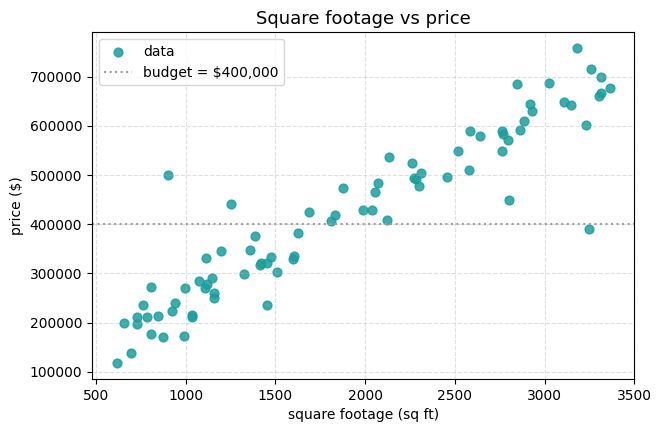

42 of 80 are over budget.


In [ ]:
#@title Run only · see the raw data
scatter_data()
plt.show()
print(f"{over_budget.sum()} of {len(over_budget)} are over budget.")

## 2 · Fit a line

A linear model is just the straight line that misses the data the least. Here you'll build one in code.

`.fit(X, y)` learns the line; `.predict(X)` uses it to guess. That's the pattern you'll reuse for every model in sklearn.

> Functions you'll use
> - `LinearRegression()`: make an unfitted line model
> - `model.fit(X, y)`: learn from data
> - `model.predict(X)`: guess outputs

Hint: `X` is already 2-D, so pass it straight in. The blanks are just the function names.

In [ ]:
#@title Edit & learn · fit a line (the core sklearn pattern)
model = LinearRegression()   # create an (unfitted) linear model
model.fit(X, price)          # fit = learn the best slope + intercept from the data
guesses = model.predict(X)   # predict = guess a price for each house

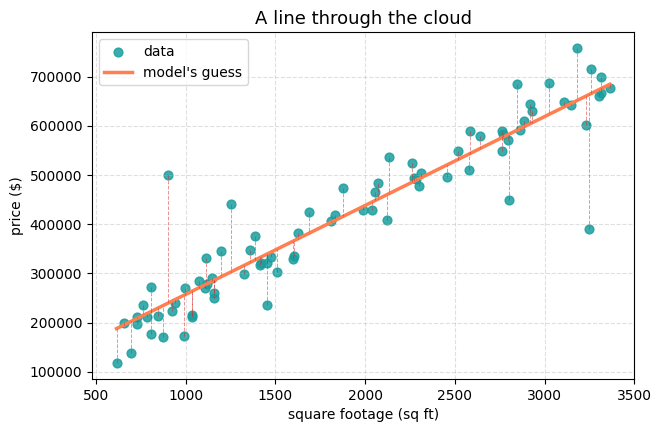

slope     ≈ $181 per sq ft
intercept ≈ $76,797


In [ ]:
#@title Run only · plot the fitted line
plot_line(model)
plt.show()
# expected: slope ~$160-200 per sq ft, intercept ~$60k-90k
print(f"slope     ≈ ${model.coef_[0]:.0f} per sq ft")   # model.coef_ holds the learned slope(s)
print(f"intercept ≈ ${model.intercept_:,.0f}")          # model.intercept_ holds the learned offset

**Check your understanding**

The model's slope came out around $181. Fill in the blanks: "For every extra ____ of house, the model expects the price to rise by about ____." Does that sound reasonable for a house?

**Answer:** "For every extra **square foot** of house, the model expects the price to rise by about **$181**." That's a believable ballpark for a per-square-foot price.

### What `.fit` just did

`.fit` solved the line in one step. Underneath, learning is a loop: predict, measure the loss (how wrong it is), nudge the line, repeat, until nudging stops helping.

The knob is the learning rate, how big a nudge to take each round:
- too small (0.001): barely moves in 200 rounds.
- about right (0.1): a smooth slide down to a low, flat loss.
- too big (1.5): it overshoots and the loss climbs.

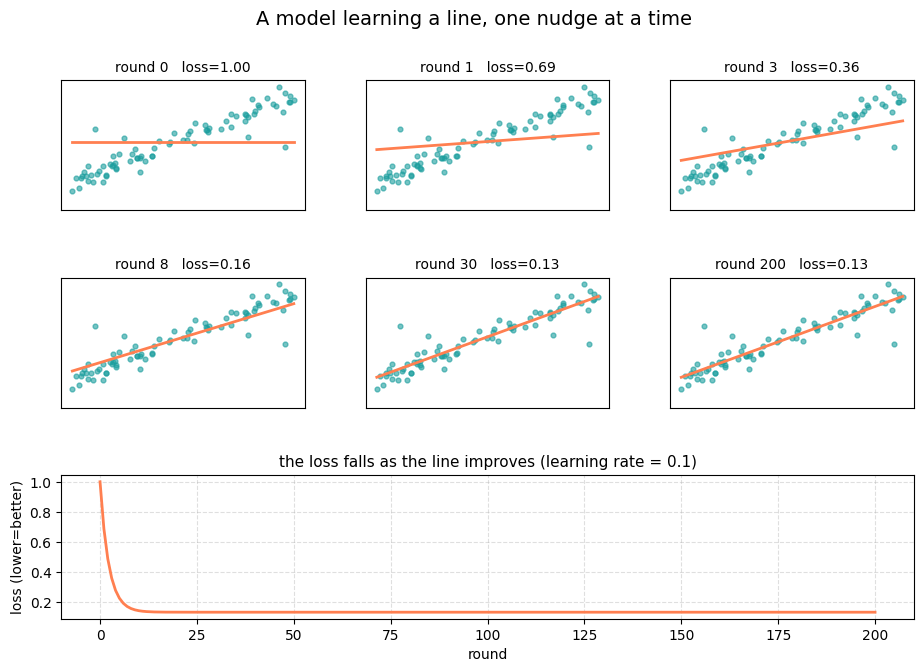

In [ ]:
#@title Edit & learn · turn the knob and watch a model learn
learning_rate = 0.1   # knob: try 0.001 (too timid) and 1.5 (too big), then re-run
show_model_learning(learning_rate)
plt.show()

**Check your understanding**

The loss curve falls quickly and then flattens out. In a sentence or two: what does that flat part tell you about whether more training rounds would help? And what would the curve look like if the model still had more to learn?

**Answer:** The flat part means more rounds wouldn't help. The line has stopped changing in any meaningful way, so the model has effectively finished learning. If it still had more to learn, the curve would still be sloping downward at the last round, or bouncing around if the learning rate were set too high.

## 3 · From a line to a probability

For a yes/no question (is this house over budget?), logistic regression squashes the line into an S-curve that outputs a probability, and a threshold turns that probability into a decision.

The new part: once we make yes/no calls, every house lands in one of four boxes, the confusion matrix:

- true positive: over budget, and we called it over
- true negative: within budget, and we called it within
- false positive: within budget, but we called it over (a false alarm)
- false negative: over budget, but we missed it

Three numbers summarize those boxes:

- accuracy: the fraction we got right overall
- precision: of the houses we called over, how many really were (this punishes false alarms)
- recall: of the houses that really were over, how many we caught (this punishes misses)

The threshold trades precision against recall. Raise it and you make fewer "over" calls: fewer false alarms but more misses. Lower it and you catch more, but with more false alarms. Watch the four boxes shift as you move it.

> Functions you'll use
> - `LogisticRegression().fit(X, y)`: learn the S-curve
> - `clf.predict_proba(X)`: gives P(within), P(over); column 1 is P(over budget)

Hint: you want the over-budget probability, which is column 1.

In [ ]:
#@title Edit & learn · probabilities, a threshold, and yes/no calls
clf = LogisticRegression(max_iter=10000).fit(X, over_budget)   # learn the S-curve

probs = clf.predict_proba(X)[:, 1]     # predict_proba gives [P(within), P(over)]; column 1 is P(over)

threshold = 0.5                # knob: try 0.3 and 0.7, then re-run
labels = (probs >= threshold).astype(int)   # turn probabilities into yes/no calls

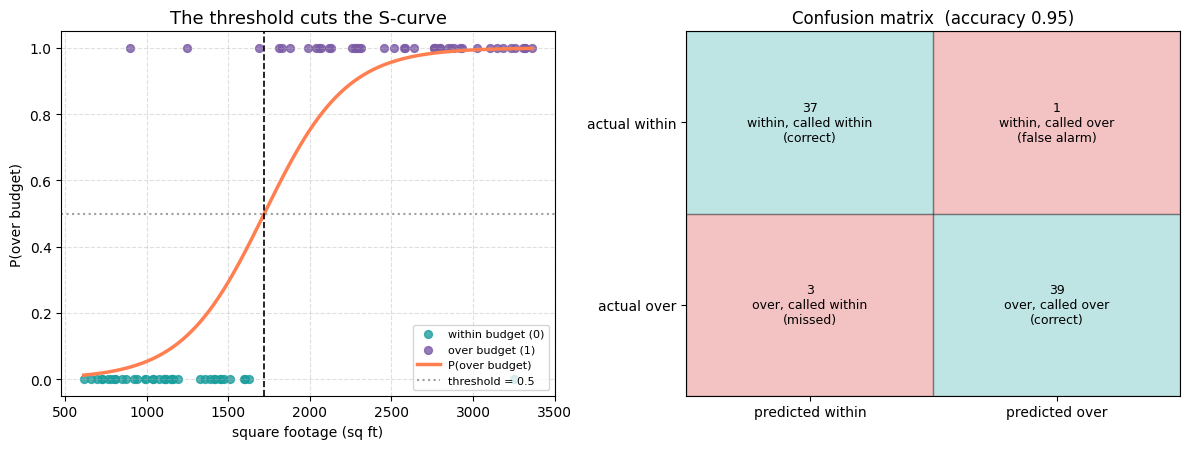

threshold = 0.5
  accuracy  = 0.95   (overall fraction we got right)
  precision = 0.97   (of the houses we called over, how many were)
  recall    = 0.93   (of the houses that were over, how many we caught)


In [ ]:
#@title Run only · the threshold, the S-curve, and the confusion matrix
report = plot_threshold_view(clf, threshold)
plt.show()
print(f"threshold = {threshold}")
print(f"  accuracy  = {report['accuracy']:.2f}   (overall fraction we got right)")
print(f"  precision = {report['precision']:.2f}   (of the houses we called over, how many were)")
print(f"  recall    = {report['recall']:.2f}   (of the houses that were over, how many we caught)")
# expected: raise the threshold -> fewer "over" calls -> recall falls, precision usually rises.

## 4 · Hold some data back

Scoring a model on the data it trained on is meaningless: it has already seen the answers. So we split: train on most of the data, judge on a part it never saw. Here that's 75% train, 25% validation.

> Functions you'll use
> - `train_test_split(X, y, test_size=, random_state=)`: returns `X_train, X_val, y_train, y_val`

Hint: the blank is just the function name. `test_size=0.25` holds out 25% for validation.

In [ ]:
#@title Edit & learn · split into train and held-out
# train_test_split shuffles, then carves off a held-out chunk you never train on
X_train, X_val, y_train, y_val = train_test_split(
    X, price, test_size=0.25, random_state=SEED)   # 25% held out; random_state = reproducible split

In [ ]:
#@title Run only · check the split sizes
print(f"train      = {len(X_train)} houses")
print(f"validation = {len(X_val)} houses")

train      = 60 houses
validation = 20 houses


**Check your understanding**

Why is it misleading to judge a model on the same data it learned from?

**Answer:** The model has already seen those answers, so a high score might just mean it memorized them. It says nothing about how it will do on new houses it has never seen. Only held-out data measures that.

Now score a plain line two ways: on the training data, and on the held-out validation data. We use R² (higher is better; 1.0 is perfect, 0 is no better than guessing the average).

The math, if you want it:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

$y_i$ is the true price, $\hat{y}_i$ is the model's prediction, and $\bar{y}$ is the average price. The top sum is the model's total squared error; the bottom is the error you'd get by always guessing the average. Match that baseline and R² = 0; predict perfectly and the top is 0, so R² = 1; do worse than the baseline and it goes negative.

Before you run it: will the two scores be close or far apart? For a simple model they should land close. In the next section a complex model pulls them apart.

In [ ]:
#@title Edit & learn · score a model honestly
line = LinearRegression().fit(X_train, y_train)         # fit on the TRAINING data only
train_score = r2_score(y_train, line.predict(X_train))  # score on data it learned from
val_score   = r2_score(y_val,   line.predict(X_val))    # score on held-out data it never saw
# expected: both land high and close (~0.8-0.9) -- a simple model doesn't overfit
print(f"train score      (R²) = {train_score:.2f}")
print(f"validation score (R²) = {val_score:.2f}")

train score      (R²) = 0.84
validation score (R²) = 0.92


## 4b · One split is just one opinion

A single held-out split gives you one number — but it depends on *which* points happened to land in the held-out set. A different split can give a noticeably different score. So which one do you trust?

Cross-validation answers that by not picking just one. It cuts the data into K equal slices ("folds"), then trains K times: each fold takes one turn as the test set while the other K−1 folds train. You get K scores; their average is a far steadier estimate of how the model does on unseen data — and every point gets tested exactly once.

The pictures below show K = 5. First the schematic — five rounds, each holding out a different gray slice. Then the *same folds on the real data*, so you can see why the rounds differ: round 1's held-out slice happens to catch the outliers, so it scores lowest.

> Functions you'll use
> - `cross_val_score(model, X, y, cv=5)`: runs the whole K-fold loop and returns one score per fold (the last number is how many folds)

Hint: the blank is just the function name. It uses the same R² score as before; higher is better.

In [ ]:
#@title Edit & learn · cross-validation: many splits, one steady score
model = LinearRegression()          # the same simple line as before

# cross_val_score runs the ENTIRE K-fold loop for you: cut the data into `cv`
# equal slices, then train + score the model `cv` times (each slice tested once).
folds = 5                                            # how many parts to cut the data into (knob: try 10)
scores = cross_val_score(model, X, price, cv=folds)  # runs the whole K-fold loop, one score per fold

print("one score per fold:", scores.round(2))
print(f"average score across {folds} folds: {scores.mean():.2f}")

one score per fold: [0.46 0.88 0.97 0.94 0.94]
average score across 5 folds: 0.84


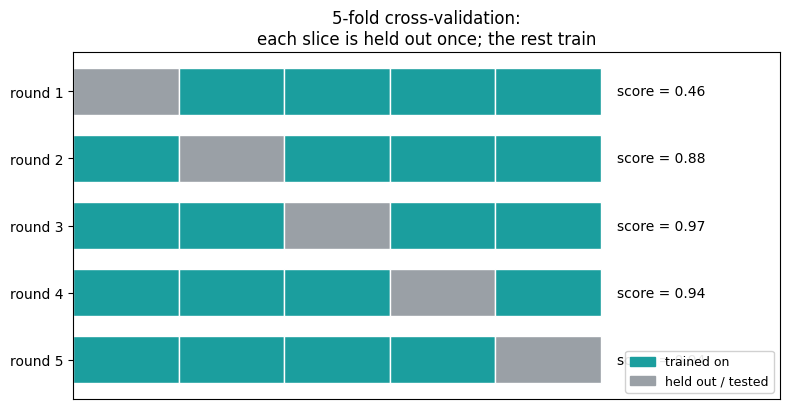

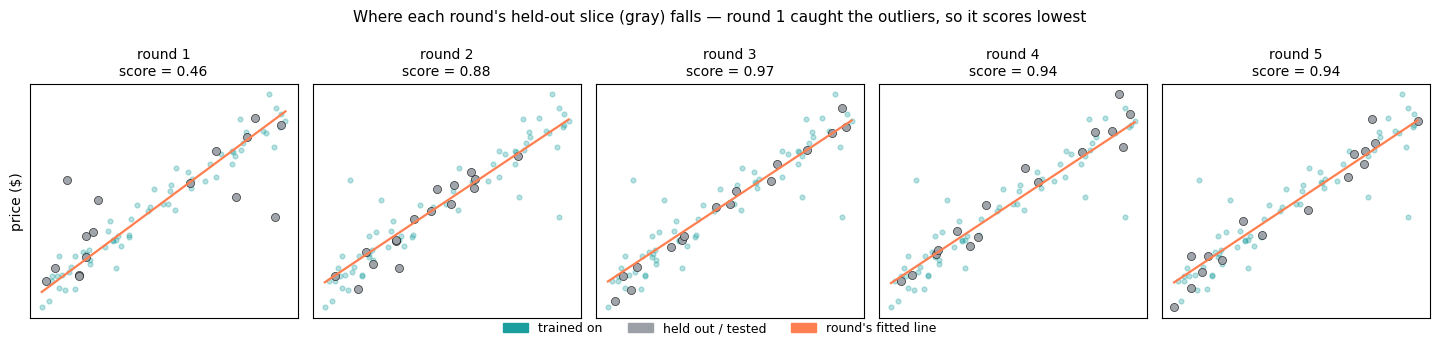

six single-split scores: [0.7, 0.83, 0.88, 0.94, 0.92, 0.93]
  -> they range from 0.70 to 0.94  (one lucky/unlucky draw)
5-fold average score : 0.84  (steadier: every point tested once)


In [ ]:
#@title Run only · the K-fold picture, and why it beats a single split
# 1) the diagram: each round holds out one gray slice, trains on the teal rest
plot_kfold_diagram(k=5, scores=scores)
plt.show()

# 1b) the SAME folds on the real data: see where each held-out slice falls.
#     round 1's gray slice catches the outliers -- that's why it scored lowest.
plot_folds_on_data(k=5)
plt.show()

# 2) the aha: a SINGLE split is just one opinion. Change which 25% you hold out
#    (random_state) and the validation score wobbles. The 5-fold average barely does.
singles = []
for s in range(6):
    Xtr, Xva, ytr, yva = train_test_split(X, price, test_size=0.25, random_state=s)
    singles.append(r2_score(yva, LinearRegression().fit(Xtr, ytr).predict(Xva)))
print("six single-split scores:", [round(v, 2) for v in singles])
print(f"  -> they range from {min(singles):.2f} to {max(singles):.2f}  (one lucky/unlucky draw)")
print(f"5-fold average score : {scores.mean():.2f}  (steadier: every point tested once)")
# expected: the single-split scores bounce ~0.1-0.2 apart; the 5-fold average sits stable in the middle.

**Check your understanding**

A single train/validation split gave one score, but the six splits above disagreed with each other. In a sentence: why is the *average* of the 5 folds a more trustworthy estimate of how the model will do on new data than any single split?

**Answer:** Any one split can be lucky or unlucky depending on which houses happen to land in the held-out set. K-fold tests on every point exactly once and averages the results, so the estimate doesn't hinge on a single random draw — it smooths out that luck.

## 5 · The overfitting gap

Let's make the model more complex. A higher polynomial degree lets the curve bend more, so it can chase individual points instead of the overall trend.

The knob starts at just 20 of the 80 houses. That's not realistic (you'd normally train on about 70%), but using so few points makes overfitting easy to see. Watch what happens as the degree climbs: the training score keeps going up, but the validation score gets worse. The gap between them is overfitting. Once you've seen it, set the knob back to a 70/30 split and the gap mostly closes.

> Functions you'll use
> - `r2_score(y_true, y_pred)`: scoring metric; higher is better

R² compares the model against a baseline that always guesses the average.

Hint: the training score grades the model on the data it learned from (`X_train`, `y_train`); the validation score grades it on the held-out data (`X_val`, `y_val`).

Before you run the sweep, predict:

- At degree 12, will the training score be high or low?
- At degree 12, will the validation score be high or low?
- Where do you think the two curves start pulling apart?

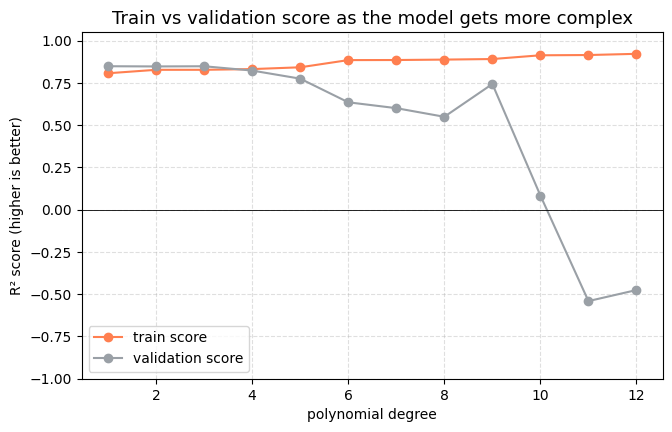

In [ ]:
#@title Edit & learn · the overfitting sweep
# The loop and plotting are provided.

test_size = 0.75   # knob: try 0.85 (only 12 train) and 0.30 (a normal 70/30 split), re-run

X_train, X_val, y_train, y_val = train_test_split(
    X, price, test_size=test_size, random_state=SEED)

degrees = range(1, 13)
train_scores, val_scores = [], []
for degree in degrees:
    # make_pipeline chains: add polynomial terms -> scale them -> fit a linear model, as one object
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                          LinearRegression()).fit(X_train, y_train)

    # train score: measured on the data the model learned from
    train_score = r2_score(
        y_train,
        model.predict(X_train),
    )

    # validation score: measured on data the model never saw
    val_score = r2_score(
        y_val,
        model.predict(X_val),
    )

    train_scores.append(train_score)
    val_scores.append(val_score)

plot_sweep(list(degrees), train_scores, val_scores)
plt.show()

In [ ]:
#@title Run only · what each knob setting shows
# test_size=0.75 (train=20): we use only 20 training points on purpose -- train score climbs
#   into the 0.9s while validation slides through 0 by ~degree 10, then dives off-chart.
# knob 0.85 (train=12): even less data -- validation craters far harder and sooner.
# knob 0.30 (train=56): a normal 70/30 split -- the gap nearly vanishes (val stays ~0.86).
#   This is why real projects train on ~70%: enough data is itself a defense against overfitting.
print("See the comments in this cell for what each knob setting should show.")

See the comments in this cell for what each knob setting should show.


**Check your understanding**

With only 20 training houses, degree 12 scores great on training but terrible on validation.
1. What has the model actually learned to do?
2. When you turn the knob to a normal 70/30 split, the gap nearly disappears. Why does more training data prevent this?

**Answer:**
1. Instead of learning the general "bigger house -> higher price" trend, it has bent itself to pass exactly through the few training points, including the noise and outliers. It memorized rather than generalized.
2. With a 70/30 split there are enough training points that the curve can't snake through all of them; the real trend dominates and there's no room left to chase noise, so the training and validation scores stay close.

### 5b · See one fit at a time

The sweep gave you numbers. This shows the actual curve at whatever degree you pick.

Degree 1 is a straight line, which already fits this data well. Push it to degree 9 or 12 and the curve turns into a wiggle that runs through every training point and bends sharply toward the outliers. The line captures the trend; the wiggle has just memorized the noise. That trade-off has a name: bias-variance.

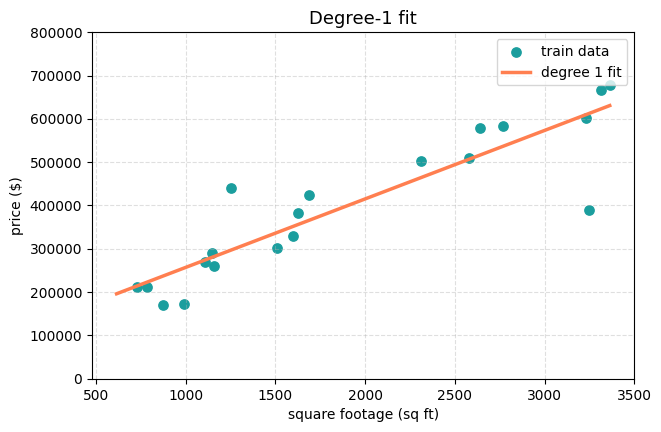

In [ ]:
#@title Edit & learn · turn the knob to see each fit
degree = 1   # knob: try 1, 4, 9, 12 and re-run
plot_poly_fit(degree, X_train, y_train)
plt.show()

## 6 · Regularization: which features actually matter? (optional)

Real datasets have many columns, and most don't matter. Here every house has ten listed features. Five really move the price: square footage, bedrooms, bathrooms, lot size, and age. The other five are things a listing might mention that have nothing to do with price: wall color, roof color, the seller's lucky number, the day it was listed, and the distance to the nearest coffee shop.

Give a plain model all ten and it leans a little on the junk -- it finds coincidences in the noise and treats them as signal. Regularization adds a penalty for leaning on features. One version, Lasso, pushes the weight of useless features all the way to zero. What is left is a short list of what actually matters, so the weights double as a readout of importance.

Turn the strength knob up and watch the five junk bars collapse to zero while the five real ones stay.

> Functions you'll use
> - `make_pipeline(StandardScaler(), Lasso(alpha=...))`: scale the features, then fit a penalized (Lasso) model
> - `LinearRegression()`: the no-penalty version, to compare against
> - `r2_score(y_true, y_pred)`: higher is better

Hint: start at strength 0, then raise it to 4000. Watch the "kept N of 10" count in the title fall.

strength = 4000   train R2 = 0.95   validation R2 = 0.94


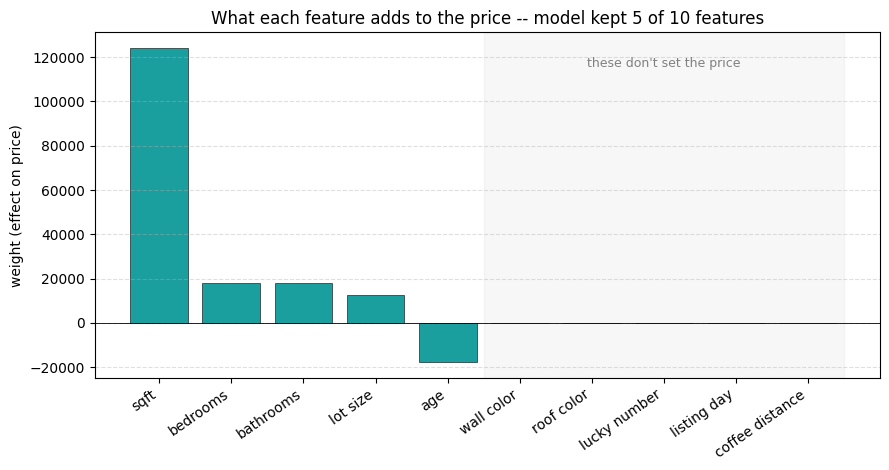

In [ ]:
#@title Edit & learn · which features actually matter?
X_train, X_val, y_train, y_val = train_test_split(
    X_house, price_house, test_size=0.25, random_state=SEED)

strength = 4000   # knob: try 0 (no penalty) and 4000 (Lasso), then re-run
# regularization just swaps the estimator inside the same scale-then-fit pipeline:
if strength == 0:
    estimator = LinearRegression()                       # no penalty -> keeps every feature
else:
    estimator = Lasso(alpha=strength, max_iter=100000)   # alpha is sklearn's name for the penalty strength
model = make_pipeline(StandardScaler(), estimator).fit(X_train, y_train)   # scale, then fit

train_r2 = r2_score(y_train, model.predict(X_train))   # fit quality on training data
val_r2   = r2_score(y_val,   model.predict(X_val))     # fit quality on held-out data
print(f"strength = {strength}   train R2 = {train_r2:.2f}   validation R2 = {val_r2:.2f}")

plot_feature_weights(model, HOUSE_FEATURES, n_real=N_REAL)   # provided chart helper: one bar per feature
plt.show()

In [ ]:
#@title Run only · what the weights show
# strength=0 (no penalty): the model leans a little on all 10 features -- the 5 gray
#   "noise" bars (lucky number, coffee distance, ...) get small nonzero weights.
# strength=4000 (Lasso): the 5 noise bars snap to exactly 0 and only the 5 real
#   drivers survive -- and validation R2 barely changes. Fewer features, same accuracy.
print("See the comments in this cell for what the weights show.")

See the comments in this cell for what the weights show.


## Use it in your own work

Everything above, distilled to the four steps you'll reuse on any dataset: split, fit, predict, score. Copy this cell and swap in your own features and target.

In [ ]:
#@title Edit & learn · the whole workflow to copy into your own work
# Replace X and price below with your own features and target.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. split FIRST, so the held-out set stays untouched
X_train, X_val, y_train, y_val = train_test_split(
    X, price, test_size=0.25, random_state=42)   # random_state = reproducible split

# 2. create and fit a model on the training data only
model = LinearRegression()
model.fit(X_train, y_train)

# 3. predict on new / held-out data
preds = model.predict(X_val)

# 4. score honestly on data the model never saw
print("R² on held-out data:", r2_score(y_val, preds))

R² on held-out data: 0.9162302270904972


## 7 · Recap

- how a model learns: nudge a bad line down the loss until nudging stops helping (`fit` does it in one call).
- fit / predict: `fit` learns from data, `predict` guesses.
- logistic regression: bends the line into a probability; a threshold turns it into a yes/no.
- train / validation split: judge on held-out data the model never saw.
- cross-validation: average the score over K folds for a steadier estimate than any single split.
- overfitting: a high training score with a collapsing validation score.
- two defenses: more data and regularization (and Lasso's surviving weights show which features matter).

Next session: new models (trees & forests) and how we grade them.

## Appendix: function cheat sheet

Build a model
- `LinearRegression()`: straight-line model
- `LogisticRegression()`: S-curve model that outputs probabilities
- `Ridge(alpha=...)`: linear model that shrinks all weights toward zero
- `Lasso(alpha=...)`: regularizer that drives useless features' weights to exactly zero (feature selection)
- `PolynomialFeatures(degree)`: lets a linear model bend into curves
- `StandardScaler()`: puts features on a common scale
- `make_pipeline(...)`: chains the above into one fit/predict object

Fit & predict
- `model.fit(X, y)`: learn from data
- `model.predict(X)`: guess outputs (hard 0/1 for classifiers)
- `clf.predict_proba(X)`: probabilities; column `[:, 1]` is P(positive class)

Split
- `train_test_split(X, y, test_size=, random_state=)` returns `X_train, X_val, y_train, y_val`

Score
- `r2_score(y_true, y_pred)`: scoring metric; higher is better (1.0 perfect, can go negative)

Cross-validate
- `cross_val_score(model, X, y, cv=K)`: runs the K-fold loop; returns K scores, average them for a steady estimate

Regularize
- bigger `alpha` = stronger penalty = simpler model
- `Ridge` shrinks all weights; `Lasso` zeros the useless ones